In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random
import sys

sys.path.append(str(Path.cwd().parent))
from src.data.preprocessing import load_yolo_labels



In [2]:

data_root = Path("../data/raw/detection/bccd")
images_dir = data_root / "images"
labels_dir = data_root / "labels"
splits_dir = data_root / "splits"


with open(splits_dir / "train.txt", 'r') as f:
    train_images = [Path(line.strip()) for line in f.readlines()]


random_images = random.sample(train_images, min(3, len(train_images)))


COLORS = {0: (0, 255, 0), 1: (255, 0, 0), 2: (255, 255, 0)}
CLASS_NAMES = ['WBC', 'RBC', 'Platelets']

plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

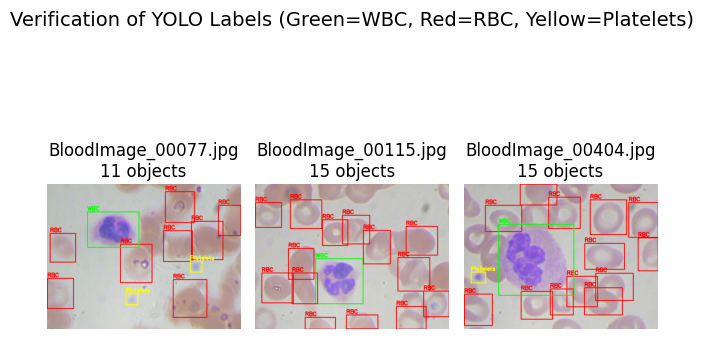


[SUCCESS] Visualized 3 images.
Total training images: 291


In [3]:

for i, img_path in enumerate(random_images):
    
    image = cv2.imread(str(img_path))
    if image is None:
        print(f"[WARNING] Could not load {img_path}")
        continue
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape
    
    
    label_path = labels_dir / f"{img_path.stem}.txt"
    
    
    boxes = load_yolo_labels(label_path, w, h)
    
    
    for class_id, (xmin, ymin, xmax, ymax) in boxes:
        color = COLORS.get(class_id, (255, 255, 255))
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.putText(image, CLASS_NAMES[class_id], (xmin, ymin - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    
    plt.subplot(1, 3, i+1)
    plt.imshow(image)
    plt.title(f"{img_path.name}\n{len(boxes)} objects")
    plt.axis('off')

plt.suptitle("Verification of YOLO Labels (Green=WBC, Red=RBC, Yellow=Platelets)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n[SUCCESS] Visualized {len(random_images)} images.")
print(f"Total training images: {len(train_images)}")